In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import re

# ============================================================
# 1. LOAD DATA
# ============================================================

# Set plotting style
sns.set_theme(style="whitegrid")

# 1. Load Data
filename = '/Users/reamchansovath/Documents/GitHub/datathon-2026/Category B Dataset/sds_datathon_gradsingapore.xlsx'
df = pd.read_excel(filename)

# Standardize Columns
rename_dict = {
    'Response ID': 'id',
    'Time Started': 'start_time',
    'Date Submitted': 'submit_time',
    'Status': 'status',
    'User Agent': 'user_agent',
    'Country': 'country',
    'Which higher education institution do you or did you study at?': 'university',
    'What is your current year of study as of 2025?': 'year',
    'What will be your highest qualification when you graduate?': 'qualification',
    'Which of the following best describes the main subject that you are studying? ': 'subject',
    'Please indicate your nationality.': 'nationality',
    'What is your gender?': 'gender',
    'Which of these statements best describes your current perception of the organisation as an employer?': 'perception',
    'Types of roles available:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_roles',
    'Career progression and development:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_career',
    'Compensation and benefits:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_comp',
    'Work-life balance and culture:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_culture',
    'Application and interview process:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_process',
    'Other - Write In (Required):What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_other',
    'Other - Write In (Required):What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  .1': 'info_other_text',
    'On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?   ': 'attractiveness',
    'Which of these factors would most motivate you to apply for a position at the organisation?  ': 'motivation',
    'Other - Write In (Required):Which of these factors would most motivate you to apply for a position at the organisation?  ': 'motivation_other'
}
df = df.rename(columns=rename_dict)
df

,id,start_time,submit_time,status,Language,SessionID,user_agent,Tags,IP Address,Longitude,...,info_roles,info_career,info_comp,info_culture,info_process,info_other,info_other_text,attractiveness,motivation,motivation_other
0,19,2025-09-02 15:03:01,2025-09-02 15:03:40,Partial,English,1756796577_68b696a123dd27.81295289,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like...,NaN,104.28.119.112,-97.821999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20,2025-09-02 15:15:32,2025-09-02 15:16:59,Disqualified,English,1756797328_68b699901c4cf6.89118890,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,57.140.24.26,4.344700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21,2025-09-02 15:18:01,2025-09-02 15:19:30,Disqualified,English,1756797478_68b69a26c5d785.44808899,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,57.140.24.26,4.344700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,22,2025-09-03 15:25:18,2025-09-03 15:27:05,Complete,English,1756884314_68b7ed5a14f861.00788803,Mozilla/5.0 (Linux; Android 15; K) AppleWebKit...,NaN,119.234.8.156,103.839302,...,Types of roles available,Career progression and development,NaN,NaN,Application and interview process,NaN,NaN,8.0,Meaningful work impact,NaN
4,23,2025-09-03 15:34:31,2025-09-03 15:34:31,Partial,English,1756884864_68b7ef80372683.27687311,Mozilla/5.0 (iPhone; CPU iPhone OS 18_5 like M...,NaN,194.11.199.111,-77.644302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2609,2628,2025-11-13 11:04:35,2025-11-13 11:31:13,Complete,English,1763003070_69154abe22f171.48493687,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like...,NaN,111.65.50.67,103.754204,...,Types of roles available,NaN,Compensation and benefits,Work-life balance and culture,NaN,NaN,NaN,7.0,Job security,NaN
2610,2629,2025-11-13 11:16:03,2025-11-13 11:19:03,Complete,English,1763003757_69154d6da70132.86627524,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like M...,NaN,119.234.36.66,103.862801,...,NaN,Career progression and development,Compensation and benefits,Work-life balance and culture,NaN,NaN,NaN,7.0,Meaningful work impact,NaN
2611,2630,2025-11-13 13:02:23,2025-11-13 13:02:56,Partial,English,1763009383_6915636777bd07.70179151,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,137.132.26.63,103.763100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2612,2631,2025-11-13 14:28:12,2025-11-13 14:29:54,Disqualified,English,1763015285_69157a75b57f41.54807902,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,119.234.52.63,103.855400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [135]:
# ============================================================
# 2. FEATURE ENGINEERING
# ============================================================

# Convert timestamps
df['start_time'] = pd.to_datetime(df['start_time'])
df['submit_time'] = pd.to_datetime(df['submit_time'])

# Time spent on survey
df['duration_sec'] = (df['submit_time'] - df['start_time']).dt.total_seconds()

# Device detection
df['is_mobile'] = df['user_agent'].str.contains(
    'Mobile|Android|iPhone',
    case=False,
    na=False
).astype(int)

df[['duration_sec', 'is_mobile']].head()

,duration_sec,is_mobile
0,39.0,1
1,87.0,0
2,89.0,0
3,107.0,1
4,0.0,1


In [136]:
# ============================================================
# 3. DATASET OVERVIEW
# ============================================================

rows, cols = df.shape
print(f"Total Respondents: {rows}")
print(f"Total Variables: {cols}")

print("\nSurvey Status Distribution:")
display(
    df['status']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

Total Respondents: 2614
Total Variables: 34

Survey Status Distribution:


status
Complete        70.7
Disqualified    17.8
Partial         11.5
Name: proportion, dtype: float64

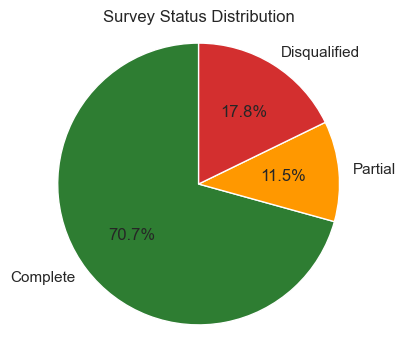

In [137]:
status_colors = {
    'Complete': '#2E7D32',
    'Partial': '#FF9800',
    'Disqualified': '#D32F2F'
}

status_counts = df['status'].value_counts().reindex(status_colors.keys())

plt.figure(figsize=(4, 4))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[status_colors[s] for s in status_counts.index]
)
plt.title('Survey Status Distribution')
plt.axis('equal')
plt.show()


In [138]:
import pandas as pd

# 1. Dataset Dimensions
# Provides the total number of survey responses and variables (columns)
rows, cols = df.shape
print(f"--- 1. Dataset Scale ---")
print(f"Total Respondents: {rows}")
print(f"Total Variables: {cols}")

# 2. Data Health (Completeness)
# Shows the ratio of Complete vs. Partial responses
print(f"\n--- 2. Survey Health ---")
status_counts = df['status'].value_counts()
status_perc = df['status'].value_counts(normalize=True) * 100
for status in status_counts.index:
    print(f"{status}: {status_counts[status]} ({status_perc[status]:.1f}%)")

# 3. Demographic Breadth
# Essential for showing the diversity of the student pool
print(f"\n--- 3. Talent Pool Diversity ---")
print(f"Unique Universities: {df['university'].nunique()}")
print(f"Unique Subjects: {df['subject'].nunique()}")
print(f"Nationalities Represented: {df['nationality'].nunique()}")

# 4. Data Types Summary
# Helps identify which columns are categorical (text) vs. numeric (ratings)
print(f"\n--- 4. Column Type Overview ---")
print(df.dtypes.value_counts())

--- 1. Dataset Scale ---
Total Respondents: 2614
Total Variables: 34

--- 2. Survey Health ---
Complete: 1848 (70.7%)
Disqualified: 465 (17.8%)
Partial: 301 (11.5%)

--- 3. Talent Pool Diversity ---
Unique Universities: 25
Unique Subjects: 20
Nationalities Represented: 3

--- 4. Column Type Overview ---
object            25
float64            5
int64              2
datetime64[ns]     2
Name: count, dtype: int64


### CATEGORY 1: Question Optimization

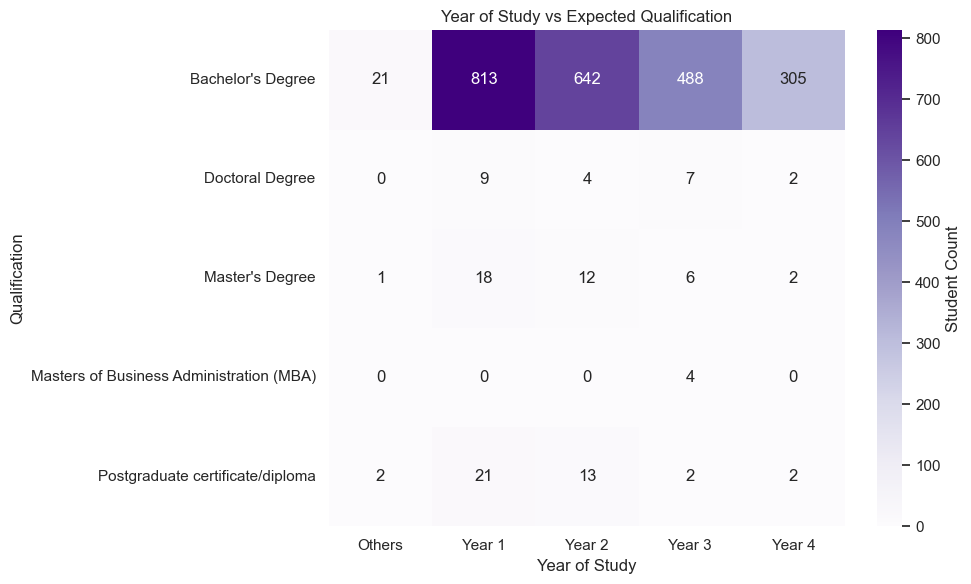

In [139]:
logic_df = pd.crosstab(df['year'], df['qualification'])

plt.figure(figsize=(10, 6))
sns.heatmap(
    logic_df.T,
    annot=True,
    fmt='d',
    cmap='Purples',
    cbar_kws={'label': 'Student Count'}
)
plt.title('Year of Study vs Expected Qualification')
plt.xlabel('Year of Study')
plt.ylabel('Qualification')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


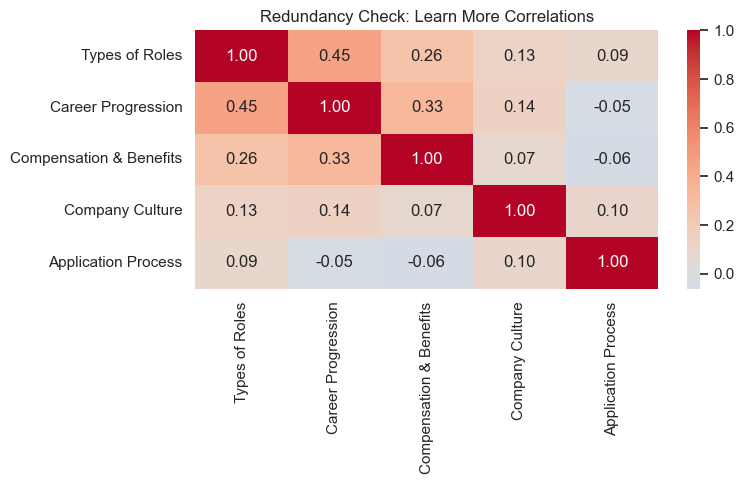

In [140]:
info_cols = ['info_roles', 'info_career', 'info_comp', 'info_culture', 'info_process']
info_binary = df[info_cols].notna().astype(int)
info_corr = info_binary.corr()

info_rename_map = {
    'info_roles': 'Types of Roles',
    'info_career': 'Career Progression',
    'info_comp': 'Compensation & Benefits',
    'info_culture': 'Company Culture',
    'info_process': 'Application Process'
}

plt.figure(figsize=(8, 5))
sns.heatmap(
    info_corr.rename(index=info_rename_map, columns=info_rename_map),
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)
plt.title('Redundancy Check: Learn More Correlations')
plt.tight_layout()
plt.show()


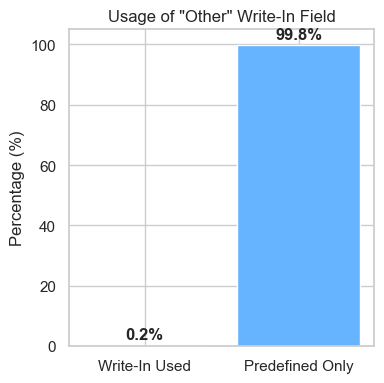

In [141]:
other_usage = df['info_other_text'].notna().mean() * 100

plt.figure(figsize=(4, 4))
plt.bar(
    ['Write-In Used', 'Predefined Only'],
    [other_usage, 100 - other_usage],
    color=['#ff9999', '#66b3ff']
)
plt.title('Usage of "Other" Write-In Field')
plt.ylabel('Percentage (%)')

for i, v in enumerate([other_usage, 100 - other_usage]):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.ylim(0, 105)
plt.tight_layout()
plt.show()


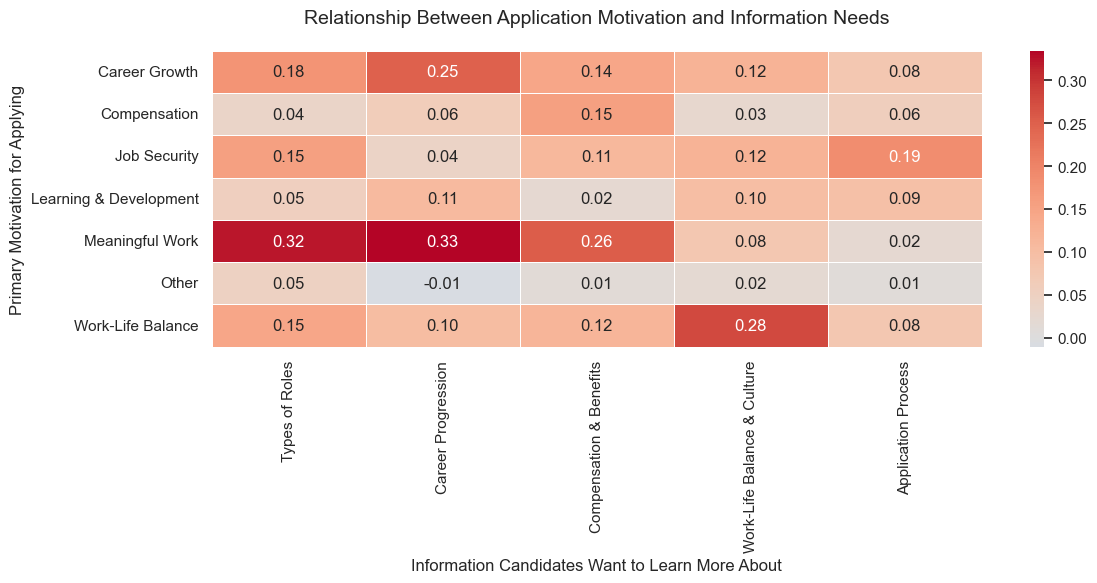

In [142]:
# ============================================================
# CLEAN + RECODE MOTIVATION × INFO INTEREST CORRELATION HEATMAP
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. One-hot encode motivation column
#    Each motivation becomes its own binary column
# ------------------------------------------------------------
motivation_dummies = pd.get_dummies(
    df['motivation'],
    prefix='motivation'
)

# ------------------------------------------------------------
# 2. Convert "info_*" columns into binary interest flags
#    1 = respondent selected this topic
#    0 = not selected
# ------------------------------------------------------------
info_cols = [
    'info_roles',
    'info_career',
    'info_comp',
    'info_culture',
    'info_process'
]

info_binary = df[info_cols].notna().astype(int)

# Rename info columns to clearer internal names
info_binary = info_binary.rename(columns={
    'info_roles': 'info_interest_roles',
    'info_career': 'info_interest_career',
    'info_comp': 'info_interest_compensation',
    'info_culture': 'info_interest_culture',
    'info_process': 'info_interest_process'
})

# ------------------------------------------------------------
# 3. Combine motivation and info interest features
# ------------------------------------------------------------
corr_input_df = pd.concat([motivation_dummies, info_binary], axis=1)

# ------------------------------------------------------------
# 4. Compute correlation matrix
#    Pearson correlation works for binary variables
# ------------------------------------------------------------
corr_matrix = corr_input_df.corr()

# Extract only Motivation × Info Interest correlations
motivation_cols = motivation_dummies.columns
info_interest_cols = info_binary.columns

motivation_info_corr = corr_matrix.loc[motivation_cols, info_interest_cols]

# ------------------------------------------------------------
# 5. Define human-readable labels for plotting
# ------------------------------------------------------------
motivation_label_map = {
    'motivation_Career growth opportunities': 'Career Growth',
    'motivation_Compensation package': 'Compensation',
    'motivation_Job security': 'Job Security',
    'motivation_Learning and development': 'Learning & Development',
    'motivation_Meaningful work impact': 'Meaningful Work',
    'motivation_Work-life balance': 'Work-Life Balance',
    'motivation_Other - Write In (Required)': 'Other'
}

info_label_map = {
    'info_interest_roles': 'Types of Roles',
    'info_interest_career': 'Career Progression',
    'info_interest_compensation': 'Compensation & Benefits',
    'info_interest_culture': 'Work-Life Balance & Culture',
    'info_interest_process': 'Application Process'
}

# Apply readable labels
motivation_info_corr_readable = motivation_info_corr.rename(
    index=motivation_label_map,
    columns=info_label_map
)

# ------------------------------------------------------------
# 6. Plot clean, business-friendly heatmap
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

sns.heatmap(
    motivation_info_corr_readable,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    'Relationship Between Application Motivation and Information Needs',
    fontsize=14,
    pad=20
)
plt.xlabel('Information Candidates Want to Learn More About', fontsize=12)
plt.ylabel('Primary Motivation for Applying', fontsize=12)

plt.tight_layout()
plt.show()


### CATEGORY 2: Survey Status

In [143]:
analysis_vars = [
    'year', 'qualification', 'nationality',
    'gender', 'university', 'subject',
    'Language', 'is_mobile'
]

df['is_complete'] = (df['status'] == 'Complete').astype(int)
ml_df = df[analysis_vars + ['is_complete']].dropna()

X = ml_df[analysis_vars].apply(lambda c: LabelEncoder().fit_transform(c.astype(str)))
y = ml_df['is_complete']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}")


Accuracy : 0.971
Precision: 0.970
Recall   : 0.993
F1-score : 0.981


Model and preprocessing objects saved:
- partial_response_model.pkl
- partial_response_label_encoders.pkl
- partial_response_feature_list.pkl

Model Performance Metrics (Partial Prediction):
Accuracy : 0.864
Precision: 0.047
Recall   : 0.211
F1-score : 0.076
ROC-AUC  : 0.577


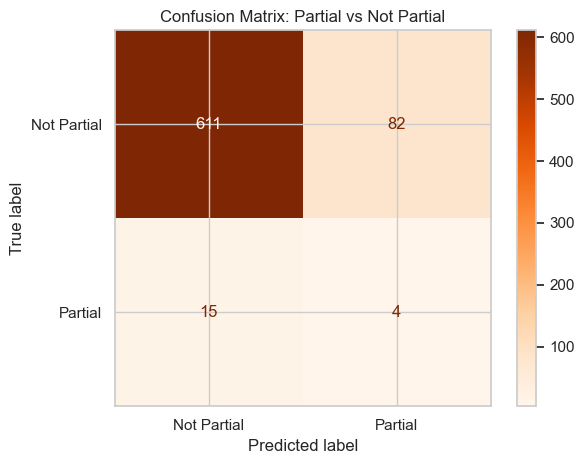

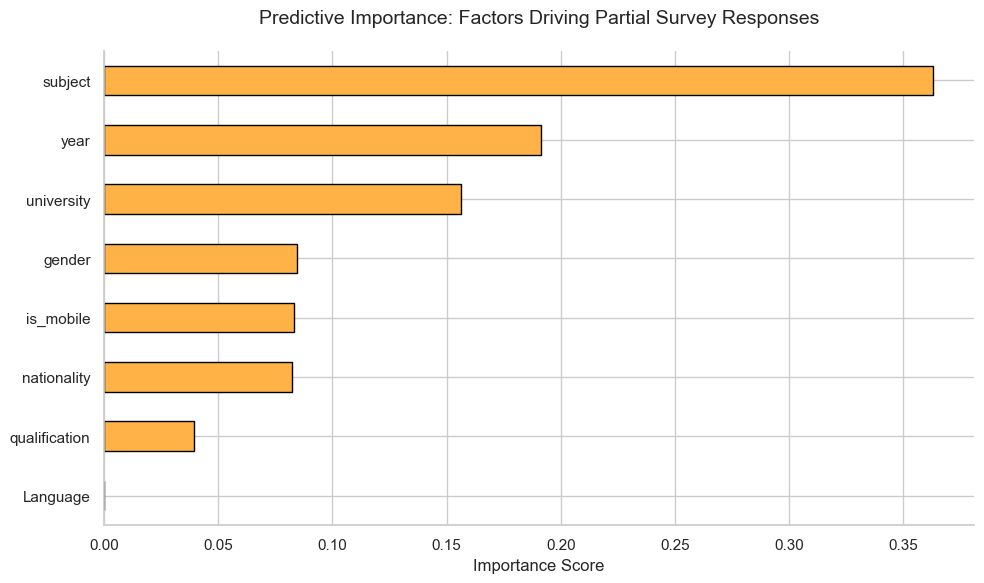

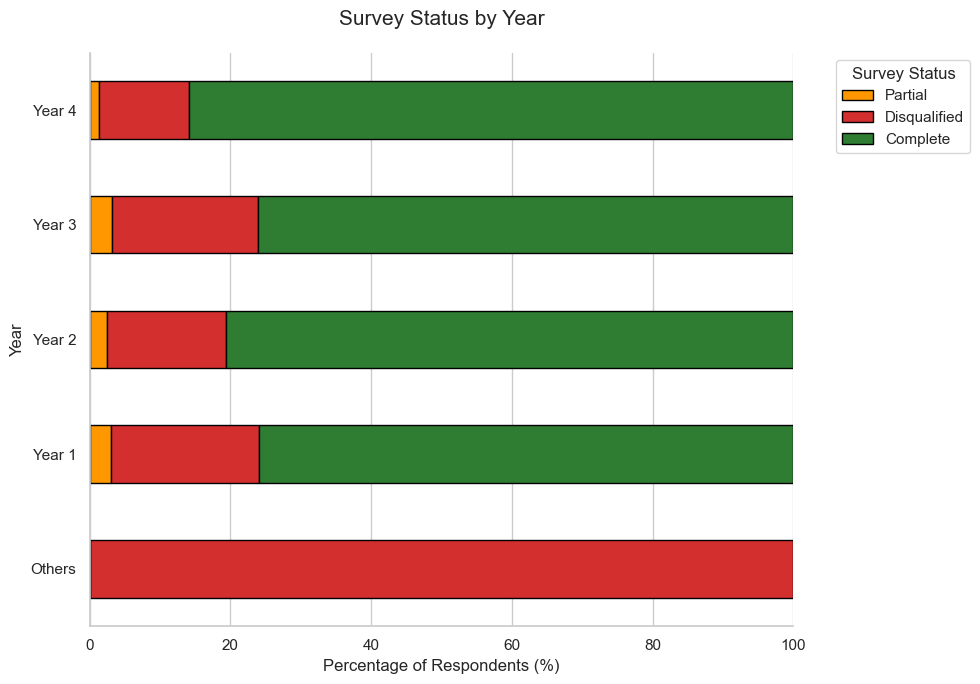

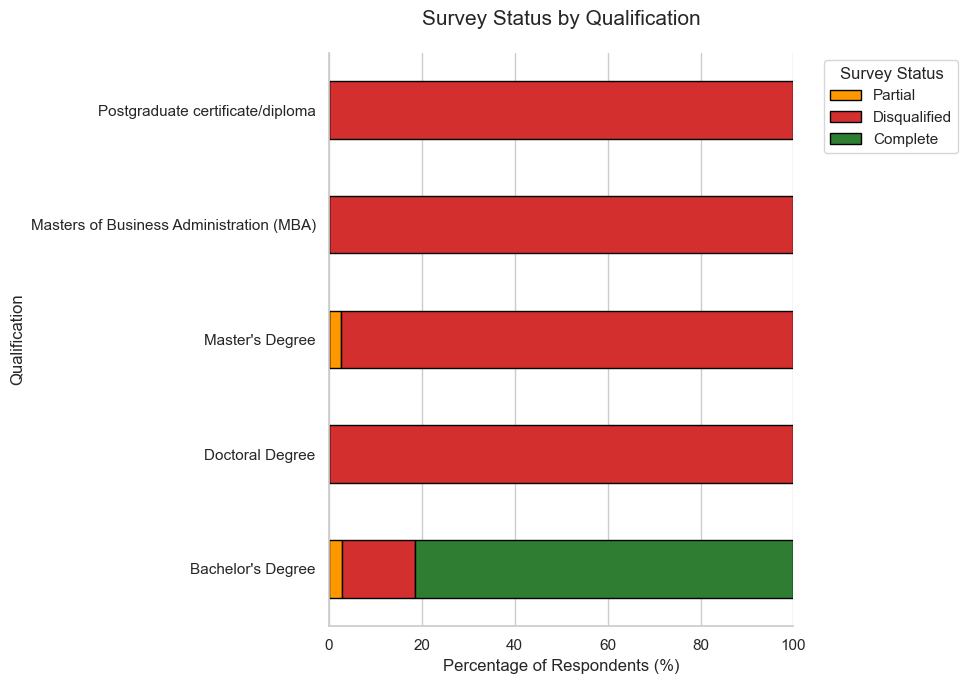

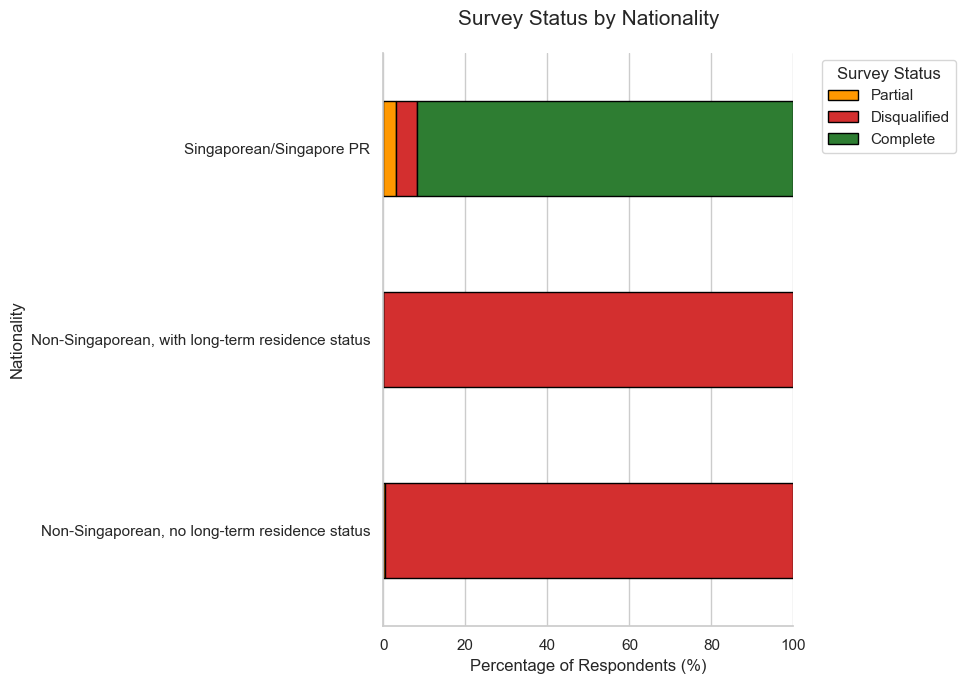

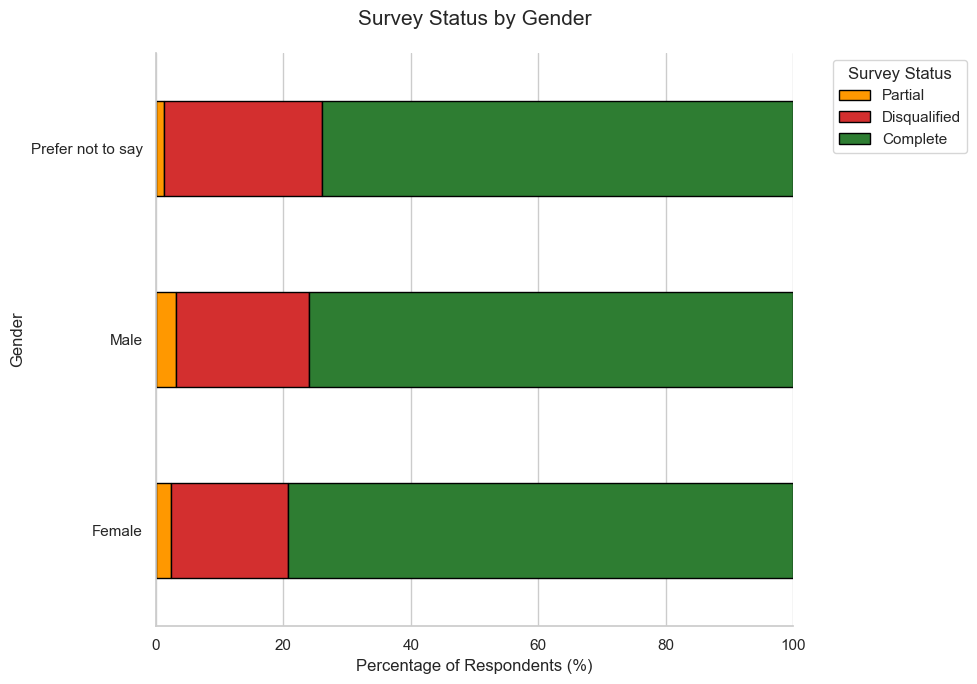

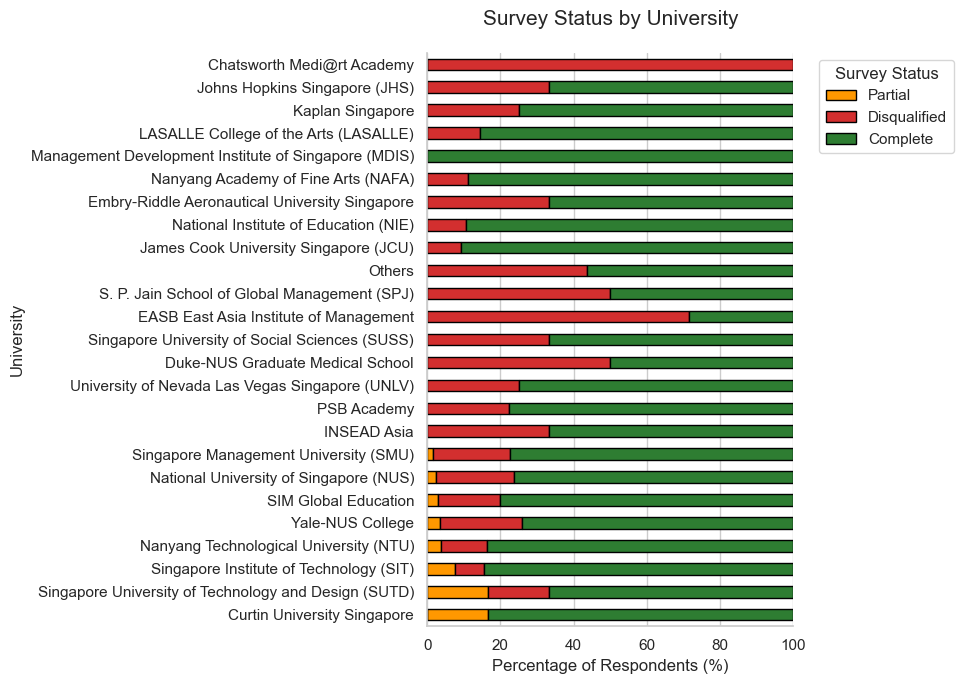

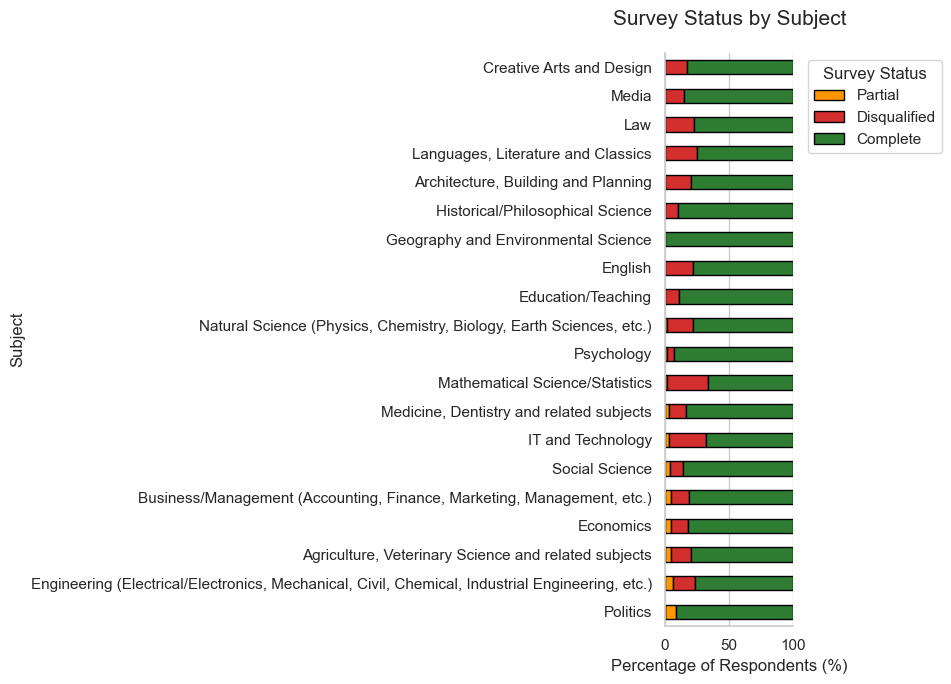

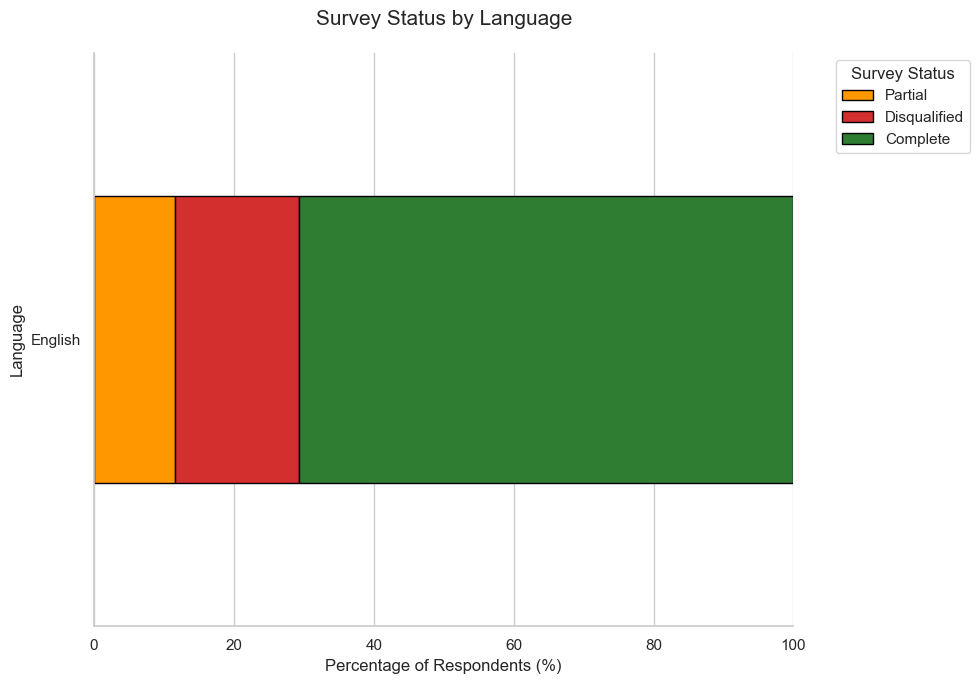

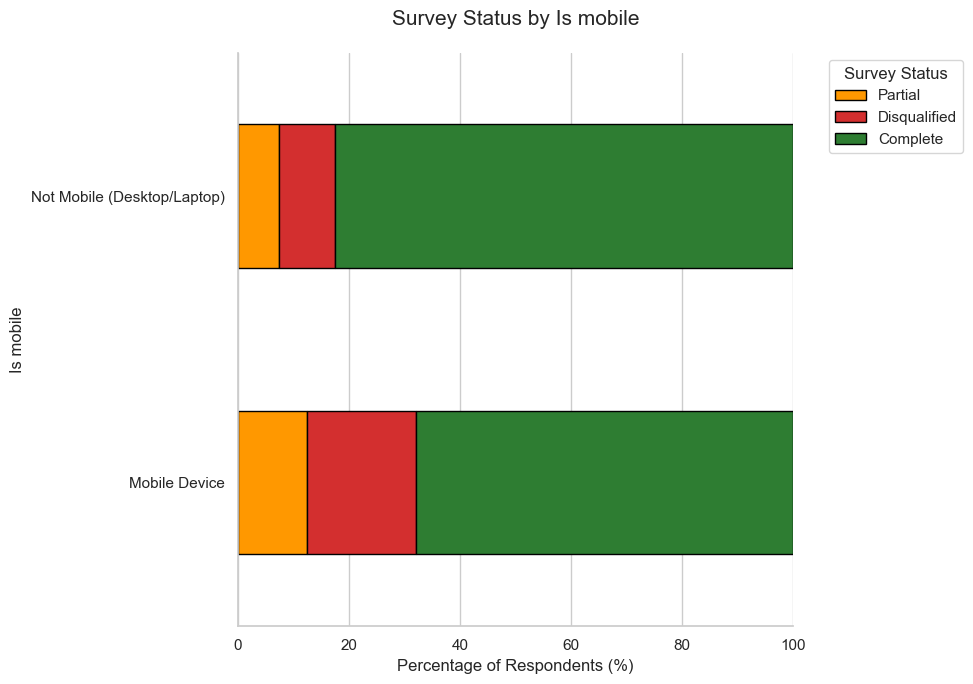

In [144]:
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Color mapping (Partial → Disqualified → Complete)
# ------------------------------------------------------------
status_colors = {
    'Partial': '#FF9800',
    'Disqualified': '#D32F2F',
    'Complete': '#2E7D32'
}
status_order = ['Partial', 'Disqualified', 'Complete']

# ------------------------------------------------------------
# Feature Selection
# ------------------------------------------------------------
analysis_vars = [
    'year',
    'qualification',
    'nationality',
    'gender',
    'university',
    'subject',
    'Language',
    'is_mobile'
]

# Mobile label for plotting
df['is_mobile_label'] = df['is_mobile'].map({
    0: 'Not Mobile (Desktop/Laptop)',
    1: 'Mobile Device'
})

# ------------------------------------------------------------
# Target Variable: PARTIAL vs NOT PARTIAL
# ------------------------------------------------------------
df['is_partial'] = (df['status'] == 'Partial').astype(int)

ml_data = df[analysis_vars + ['is_partial']].dropna()

X = ml_data[analysis_vars].copy()
y = ml_data['is_partial']

# ------------------------------------------------------------
# Encode categorical variables and STORE encoders
# ------------------------------------------------------------
label_encoders = {}

for col in analysis_vars:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le  # save encoder

# ------------------------------------------------------------
# Train / Test Split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Train Random Forest Model
# ------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

# ------------------------------------------------------------
# SAVE MODEL + ENCODERS
# ------------------------------------------------------------
joblib.dump(rf, 'partial_response_model.pkl')
joblib.dump(label_encoders, 'partial_response_label_encoders.pkl')
joblib.dump(analysis_vars, 'partial_response_feature_list.pkl')

print("Model and preprocessing objects saved:")
print("- partial_response_model.pkl")
print("- partial_response_label_encoders.pkl")
print("- partial_response_feature_list.pkl")

# ------------------------------------------------------------
# Prediction & Metrics
# ------------------------------------------------------------
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\nModel Performance Metrics (Partial Prediction):")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Partial', 'Partial']
)
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix: Partial vs Not Partial')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Feature Importance Plot
# ------------------------------------------------------------
importances = pd.Series(
    rf.feature_importances_,
    index=analysis_vars
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(
    kind='barh',
    color='#FFB347',
    edgecolor='black'
)
plt.title(
    'Predictive Importance: Factors Driving Partial Survey Responses',
    fontsize=14,
    pad=20
)
plt.xlabel('Importance Score')
sns.despine()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Status Distribution Plots
# University, Subject, Mobile sorted by PARTIAL rate
# ------------------------------------------------------------
sort_by_partial_vars = ['university', 'subject', 'is_mobile']

for col in analysis_vars:
    plt.figure(figsize=(10, 7))
    
    col_to_plot = 'is_mobile_label' if col == 'is_mobile' else col
    
    status_dist = (
        pd.crosstab(df[col_to_plot], df['status'], normalize='index') * 100
    )

    available_statuses = [s for s in status_order if s in status_dist.columns]
    status_dist = status_dist[available_statuses]

    if col in sort_by_partial_vars and 'Partial' in status_dist.columns:
        status_dist = status_dist.sort_values(by='Partial', ascending=False)

    status_dist.plot(
        kind='barh',
        stacked=True,
        ax=plt.gca(),
        color=[status_colors[s] for s in available_statuses],
        edgecolor='black'
    )

    plt.title(f'Survey Status by {col.replace("_", " ").capitalize()}', fontsize=15, pad=20)
    plt.xlabel('Percentage of Respondents (%)')
    plt.ylabel(col.replace("_", " ").capitalize())
    plt.xlim(0, 100)
    plt.yticks(rotation=0)

    plt.legend(title='Survey Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    sns.despine()
    plt.tight_layout()
    plt.show()


/var/folders/mb/9y6pxy613_x_ync4yzkhl_1m0000gn/T/ipykernel_22973/1199247553.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='duration_sec', y='status', data=df[df['duration_sec'] <= 600],


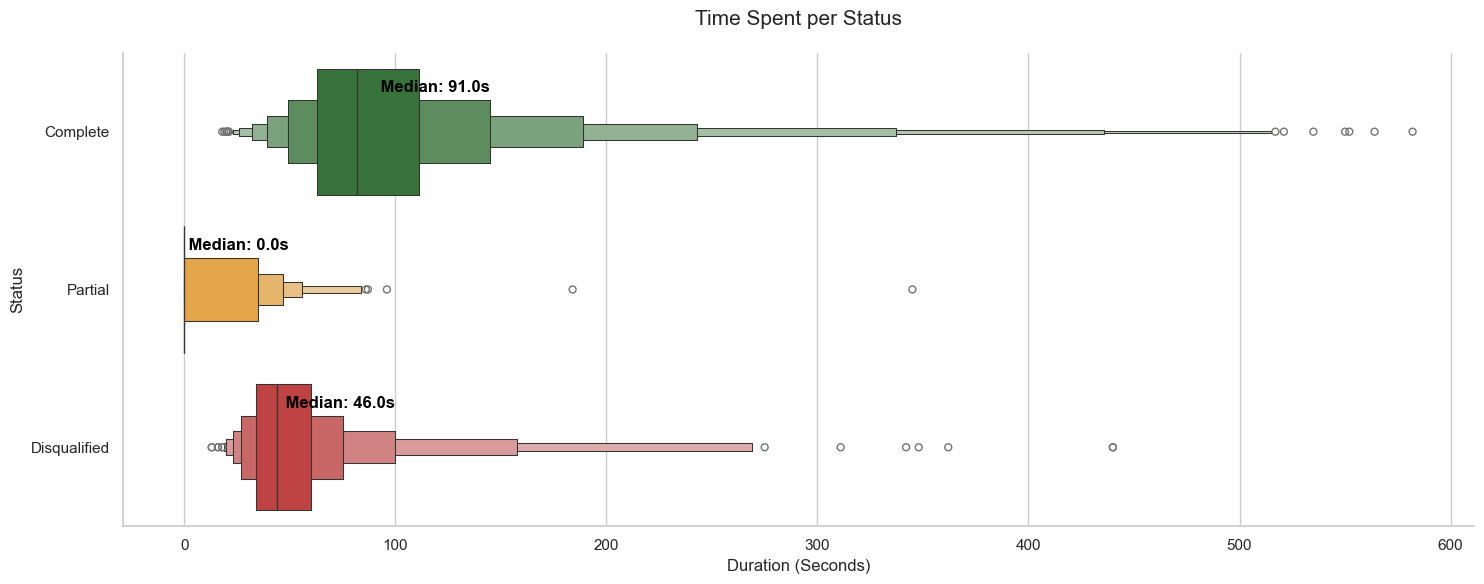

In [145]:
plt.figure(figsize=(15, 6))

# Boxen plot is great for large data and shows distribution depth
sns.boxenplot(x='duration_sec', y='status', data=df[df['duration_sec'] <= 600],
              order=['Complete', 'Partial', 'Disqualified'],
              palette=status_colors)

plt.title('Time Spent per Status', fontsize=15, pad=20)
plt.xlabel('Duration (Seconds)', fontsize=12)
plt.ylabel('Status', fontsize=12)

# Add median text labels
for i, status in enumerate(['Complete', 'Partial', 'Disqualified']):
    med = df[df['status'] == status]['duration_sec'].median()
    plt.text(med, i - 0.25, f' Median: {med:.1f}s', fontweight='bold', color='black')

sns.despine()
plt.tight_layout()
plt.show()

/var/folders/mb/9y6pxy613_x_ync4yzkhl_1m0000gn/T/ipykernel_22973/491672194.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


     question  num_dropoffs  percentage
0  university           237       78.74
1  perception            62       20.60
2        year             1        0.33
3  info_roles             1        0.33


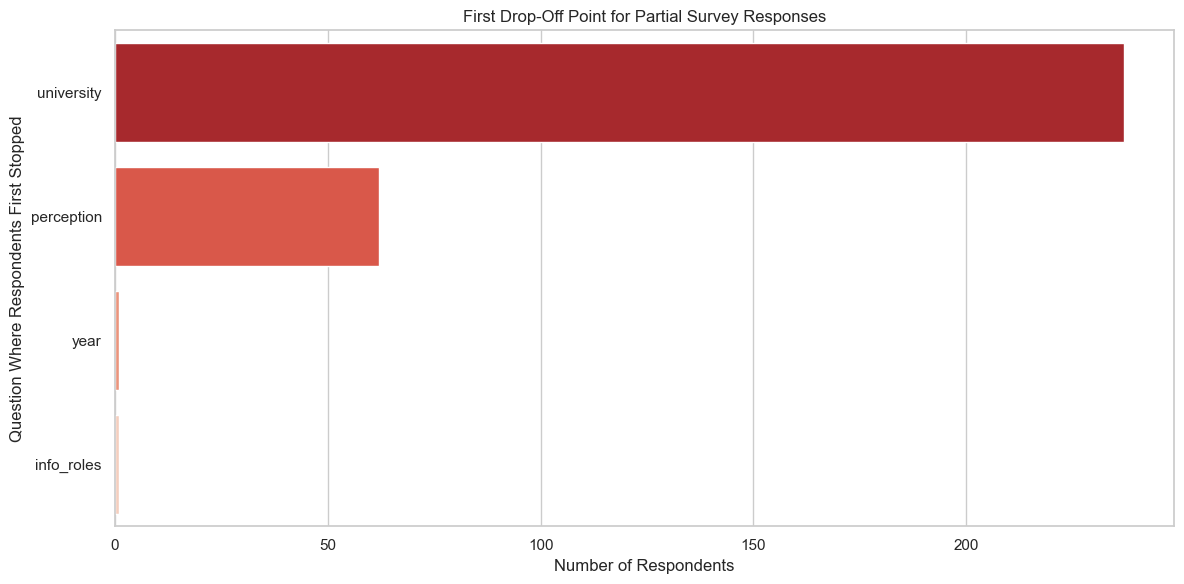

In [146]:
# ============================================
# ANALYSE DROP-OFF POINTS FOR PARTIAL RESPONSES
# ============================================

# ------------------------------------------------
# 1. Define the survey question order
#    This MUST reflect the actual order shown to respondents
# ------------------------------------------------
survey_questions = [
    'university',
    'year',
    'qualification',
    'subject',
    'nationality',
    'gender',
    'perception',
    'info_roles',
    'info_career',
    'info_comp',
    'info_culture',
    'info_process',
    'info_other_text',
    'attractiveness',
    'motivation',
    'motivation_other'
]

# ------------------------------------------------
# 2. Filter only Partial responses
# ------------------------------------------------
partial_df = df[df['status'] == 'Partial'].copy()

# ------------------------------------------------
# 3. Function to find the first unanswered question
#    For each respondent, we scan questions in order
#    and return the first question that is blank or NaN
# ------------------------------------------------
def first_blank_question(row):
    for q in survey_questions:
        if pd.isna(row[q]) or str(row[q]).strip() == "":
            return q
    return None  # Respondent answered all listed questions

# Apply the function row-by-row
partial_df['first_dropoff_question'] = partial_df.apply(
    first_blank_question,
    axis=1
)

# ------------------------------------------------
# 4. Aggregate results to see where respondents drop off
# ------------------------------------------------
dropoff_summary = (
    partial_df['first_dropoff_question']
    .value_counts()
    .reset_index()
)

dropoff_summary.columns = ['question', 'num_dropoffs']

# Calculate percentage contribution of each drop-off point
dropoff_summary['percentage'] = (
    dropoff_summary['num_dropoffs'] /
    dropoff_summary['num_dropoffs'].sum() * 100
).round(2)

# Display the summary table
print(dropoff_summary)

# ------------------------------------------------
# 5. Visualise drop-off "cliffs"
#    This shows which question causes the most exits
# ------------------------------------------------
plt.figure(figsize=(12, 6))

sns.barplot(
    data=dropoff_summary,
    x='num_dropoffs',
    y='question',
    palette='Reds_r'
)

plt.title('First Drop-Off Point for Partial Survey Responses')
plt.xlabel('Number of Respondents')
plt.ylabel('Question Where Respondents First Stopped')

plt.tight_layout()
plt.show()
